In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import math

In [3]:
iso = pd.read_csv('output699161339857.dat.txt', sep=r'\s+', comment='#')
df = pd.read_csv('gd1_raw.csv')
iso

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Y,Xc,Xn,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag
0,0.000098,-2.19174,10.08,0.100000,1.171106,0.100,-2.780,3.5588,5.405,1,...,0.2546,0.000018,0.000005,0.000044,-1.0,0.000100,11.721,12.100,13.084,11.149
1,0.000098,-2.19174,10.08,0.109821,1.248275,0.109,-2.632,3.5741,5.356,1,...,0.2564,0.000018,0.000005,0.000044,-1.0,0.000100,11.349,11.678,12.576,10.768
2,0.000098,-2.19174,10.08,0.129464,1.378675,0.129,-2.390,3.5966,5.277,1,...,0.2594,0.000018,0.000005,0.000044,-1.0,0.000100,10.744,11.008,11.797,10.155
3,0.000098,-2.19174,10.08,0.149107,1.485596,0.149,-2.227,3.6079,5.220,1,...,0.2613,0.000018,0.000005,0.000044,-1.0,0.000100,10.336,10.568,11.309,9.743
4,0.000098,-2.19174,10.08,0.168750,1.575614,0.168,-2.100,3.6152,5.176,1,...,0.2621,0.000018,0.000005,0.000044,-1.0,0.000100,10.020,10.232,10.943,9.424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.000098,-2.19174,10.08,0.799933,2.418701,0.677,3.188,3.6499,0.632,8,...,0.2487,0.000013,0.000012,0.000041,-1.0,0.000142,-3.201,-3.007,-2.296,-3.806
204,0.000098,-2.19174,10.08,0.799934,2.418701,0.661,3.246,3.6459,0.548,8,...,0.2487,0.000013,0.000012,0.000041,-1.0,0.000142,-3.346,-3.128,-2.389,-3.945
205,0.000098,-2.19174,10.08,0.799934,2.418701,0.644,3.272,3.6439,0.503,8,...,0.2487,0.000013,0.000012,0.000041,-1.0,0.000142,-3.409,-3.178,-2.423,-4.004
206,0.000098,-2.19174,10.08,0.799935,2.418702,0.626,3.282,3.6428,0.475,8,...,0.2487,0.000013,0.000012,0.000041,-1.0,0.000142,-3.436,-3.197,-2.432,-4.030


In [4]:
df

,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,g,bp,rp,bp_rp,radial_velocity,radial_velocity_error,ruwe
0,3028877015220386560,116.456113,-15.523901,0.432902,0.072100,-3.683772,0.062950,3.311741,0.057357,17.193275,17.570854,16.674803,0.896051,NaN,NaN,1.018883
1,3028877285798759296,116.440921,-15.509863,-0.085740,0.224561,-0.478370,0.182951,1.956409,0.190924,18.911531,19.370520,18.325485,1.045034,NaN,NaN,0.985222
2,3028877324458031360,116.454356,-15.518681,0.134038,0.152380,-2.040403,0.124655,-0.393748,0.129883,18.299320,18.851760,17.628939,1.222822,NaN,NaN,0.964404
3,3028879282959525248,116.315437,-15.513610,-0.583074,0.562074,-1.989513,0.427225,0.961223,0.410778,20.009432,20.752394,19.060066,1.692327,NaN,NaN,0.999649
4,3028879313023300992,116.294922,-15.519140,-0.026257,0.538958,-1.326397,0.381779,3.454656,0.376938,19.896765,20.344088,19.181350,1.162737,NaN,NaN,0.973528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3106478,693556374135724672,140.601168,24.765237,0.838691,0.026554,-1.822685,0.028172,-0.540270,0.024012,14.682658,15.008605,14.188639,0.819966,NaN,NaN,0.974912
3106479,693556683373376896,140.735822,24.734117,0.144730,0.211132,-4.983037,0.248911,-2.754344,0.177768,18.488369,18.930973,17.862806,1.068167,NaN,NaN,1.095026
3106480,693556855172069376,140.701811,24.751698,0.253507,0.209942,4.382272,0.269550,-7.046062,0.209996,18.674997,19.303408,17.922993,1.380415,NaN,NaN,0.900905
3106481,693559432152438656,140.605760,24.775642,0.744791,0.149246,0.100332,0.164898,-0.913998,0.132929,18.080950,18.982998,17.163570,1.819427,NaN,NaN,0.984343


In [5]:
d = 8500 #parsecs
distance_modulus = 5*math.log10(d) - 5

iso['G_app'] = iso['Gmag'] + distance_modulus
iso['color'] = iso['G_BPmag'] - iso['G_RPmag']
df['color'] = df['bp'] - df['rp']

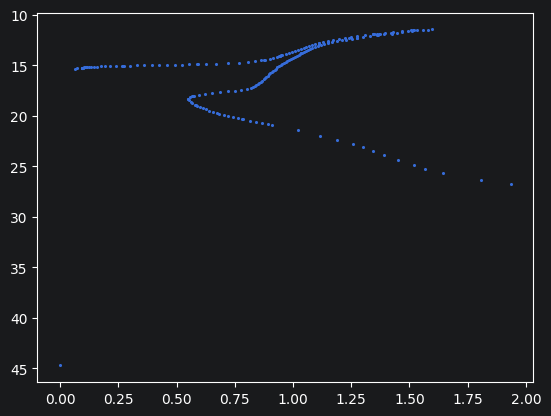

In [25]:
plt.scatter(iso['color'], iso['G_app'], s=1.5)
plt.gca().invert_yaxis()
plt.show()

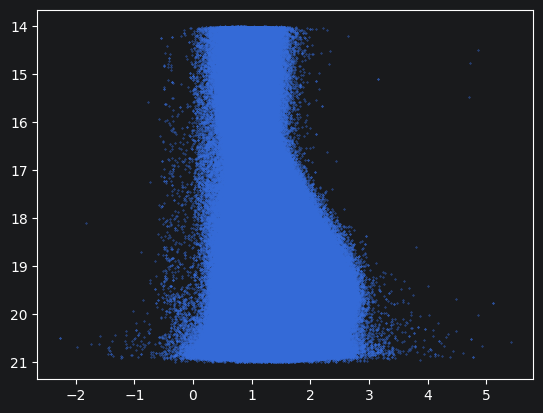

In [7]:
plt.scatter(df['color'], df['g'], s=0.1)
plt.gca().invert_yaxis()
plt.show()

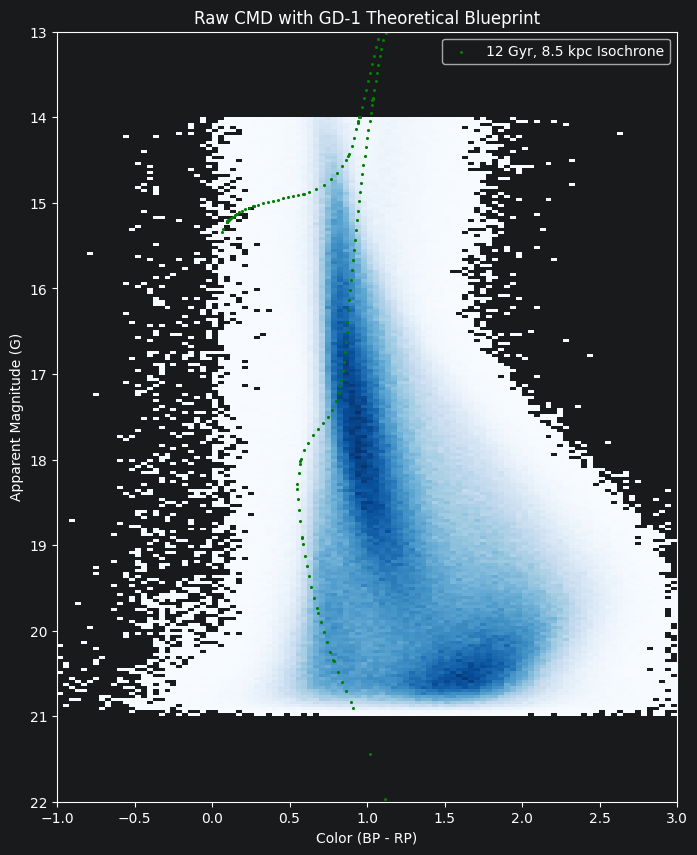

In [22]:
plt.figure(figsize=(8, 10))

plt.hist2d(df['color'], df['g'], bins=200, cmap='Blues', cmin=1)

plt.scatter(iso['color'], iso['G_app'], color='green', s=1.5, label='12 Gyr, 8.5 kpc Isochrone')

plt.title('Raw CMD with GD-1 Theoretical Blueprint')
plt.xlabel('Color (BP - RP)')
plt.ylabel('Apparent Magnitude (G)')
plt.gca().invert_yaxis()

plt.xlim(-1, 3)
plt.ylim(22, 13)
plt.legend()

plt.show()

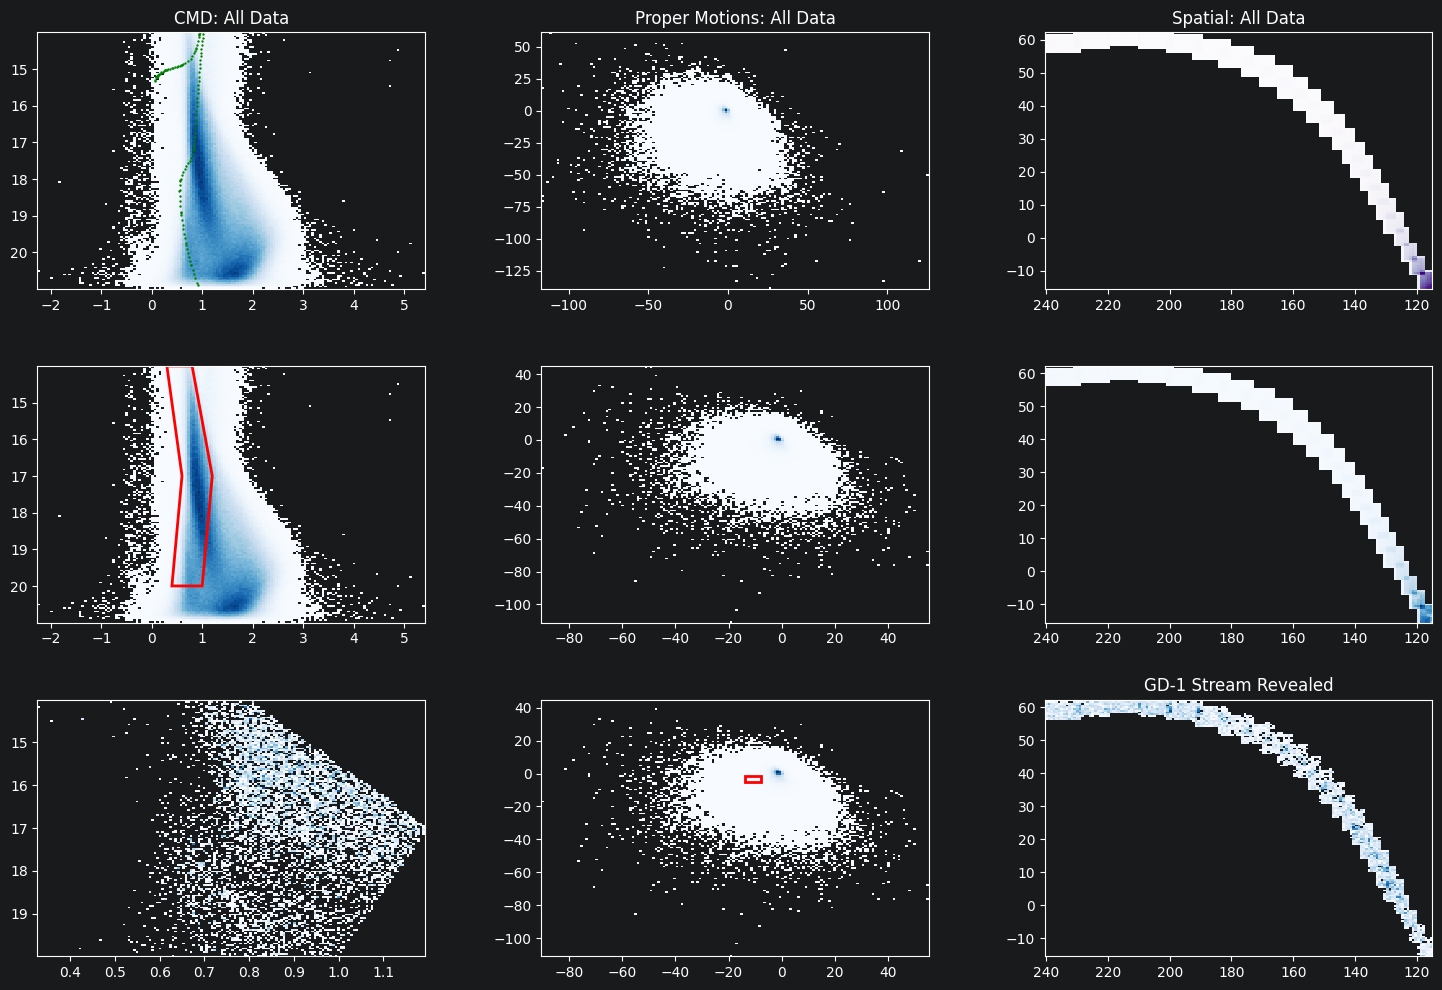

In [20]:
photo_vertices = [
    (0.3, 14),
    (0.8, 14),
    (1.2, 17),
    (1.0, 20),
    (0.4, 20),
    (0.6, 17)
]
photo_path = Path(photo_vertices)
points_cmd = np.vstack((df['color'], df['g'])).T
photo_mask = photo_path.contains_points(points_cmd)

pm_vertices = [
    (-14, -1.5),
    (-8, -1.5),
    (-8, -5.0),
    (-14, -5.0)
]
pm_path = Path(pm_vertices)
points_pm = np.vstack((df['pmra'], df['pmdec'])).T
pm_mask = pm_path.contains_points(points_pm)

df_photo_only = df[photo_mask]
df_final = df[photo_mask & pm_mask]


fig, axs = plt.subplots(3, 3, figsize=(18, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

def plot_hist(ax, x, y, bins=150, cmap='Blues', invert_y=False):
    ax.hist2d(x, y, bins=bins, cmap=cmap, cmin=1)
    if invert_y:
        ax.invert_yaxis()

# --- ROW 1: All Data ---
# Left:
plot_hist(axs[0,0], df['color'], df['g'], invert_y=True)
axs[0,0].scatter(iso['color'], iso['G_app'], color='green', label='12Gyr, 8.5kpc', s=0.5)
axs[0,0].set_title('CMD: All Data')

# Center:
plot_hist(axs[0,1], df['pmra'], df['pmdec'])
axs[0,1].set_title('Proper Motions: All Data')

# Right:
plot_hist(axs[0,2], df['ra'], df['dec'], cmap='Purples')
axs[0,2].invert_xaxis()
axs[0,2].set_title('Spatial: All Data')

# --- ROW 2: Photometric Selection ---
# Left:
plot_hist(axs[1,0], df['color'], df['g'], invert_y=True)
patch = plt.Polygon(photo_vertices, closed=True, fill=False, edgecolor='red', lw=2)
axs[1,0].add_patch(patch)

# Center:
plot_hist(axs[1,1], df_photo_only['pmra'], df_photo_only['pmdec'])

# Right:
plot_hist(axs[1,2], df_photo_only['ra'], df_photo_only['dec'], cmap='Blues')
axs[1,2].invert_xaxis()

# --- ROW 3: Kinematic Selection ---
# Left:
plot_hist(axs[2,0], df_final['color'], df_final['g'], invert_y=True)

# Center:
plot_hist(axs[2,1], df_photo_only['pmra'], df_photo_only['pmdec'])
patch = plt.Polygon(pm_vertices, closed=True, fill=False, edgecolor='red', lw=2)
axs[2,1].add_patch(patch)

# Right
plot_hist(axs[2,2], df_final['ra'], df_final['dec'], cmap='Blues')
axs[2,2].invert_xaxis()
axs[2,2].set_title('GD-1 Stream Revealed')

plt.show()